In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

from cleaning_utils import clean_dataset2

In [2]:
raw_df = pd.read_csv('OML_4G_DATA_OSS.csv')
df = clean_dataset2(raw_df)

df.head()

,Time,eNodeB_Function_Name,Cell_Name,Frequency_band,Avg_DL_User_Thrput_kbps,Avg_DL_Traffic_Active_User,Date,Hour
0,2024-05-27,1288_KKO_KATI_4G,1288_KKO_KATI_1_L800,20,7543.2661,2.6076,2024-05-27,0
1,2024-05-27,1324_BKO_SOGONIKO_4G,1324_BKO_SOGONIKO_3_L800,20,9686.8516,0.8624,2024-05-27,0
2,2024-05-27,1560_BKO_SENOU-MEDINE_4G,1560_BKO_SENOU-MEDINE_2_L1800,3,12827.9154,1.8092,2024-05-27,0
3,2024-05-27,1605_BKO_NIARELAMosque_4G,1605_BKO_NIARELAMosque_1_L700,28,0.0000,0.0000,2024-05-27,0
4,2024-05-27,1634_BKO_DOUMANZANA_4G,1634_BKO_DOUMANZANA_3_L1800,3,18474.4263,0.7931,2024-05-27,0


In [3]:
""""" 
KPI 1: DL Throughput
KPI 2: DL Active User
"""""

'"" \nKPI 1: DL Throughput\nKPI 2: DL Active User\n'

## Traffic Active User Forecasting

In [4]:
def prepare_ml_dataset(df, cell_name, target_col='Avg_DL_Traffic_Active_User',
                       lag_days=[1, 2, 3, 7], include_kpi1=True):
    df_cell = df[df['Cell_Name'] == cell_name].sort_values('Time').copy()

    # Rename for consistency
    df_cell = df_cell[['Time', 'Avg_DL_User_Thrput_kbps', 'Avg_DL_Traffic_Active_User']].copy()
    df_cell.rename(columns={'Time': 'ds', 'Avg_DL_User_Thrput_kbps': 'kpi1', 'Avg_DL_Traffic_Active_User': 'kpi2'}, inplace=True)

    # Create lag features for KPI 2 (target)
    for lag in lag_days:
        df_cell[f'kpi2_lag_{lag}'] = df_cell['kpi2'].shift(lag)

    # Add lag features for KPI 1
    if include_kpi1:
        for lag in lag_days:
            df_cell[f'kpi1_lag_{lag}'] = df_cell['kpi1'].shift(lag)

    # Add time features
    df_cell['dayofweek'] = df_cell['ds'].dt.dayofweek
    df_cell['month'] = df_cell['ds'].dt.month

    # Drop NA from lagging
    df_cell = df_cell.dropna().reset_index(drop=True)

    return df_cell

### L800 Cell

In [5]:
df_ml = prepare_ml_dataset(df, '4262_KYS_KENIEBA_3_L800')

In [6]:
def train_xgb_on_kpi2(df_ml, target='kpi2', test_ratio=0.2):
    # 1. Split
    X = df_ml.drop(columns=['ds', target])
    y = df_ml[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)

    # 2. Train
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 3. Predict
    y_pred = model.predict(X_test)

    # 4. Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    print(f"XGBoost Forecast Evaluation for Traffic Active User - L800")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # 5. Plot
    plt.figure(figsize=(12, 6))

    plt.plot(y_test.reset_index(drop=True), label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title("XGBoost Forecast for Traffic Active Users - L800")
    plt.xlabel('Days')
    plt.ylabel('Avg DL Traffic Active Users')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 6. Feature importance
    xgb.plot_importance(model, height=0.5, max_num_features=10)
    plt.title("Top 10 Feature Importances")
    plt.show()

    return model, y_test, y_pred

XGBoost Forecast Evaluation for Traffic Active User - L800
MAE: 17.35
RMSE: 23.07
MAPE: 33.97%


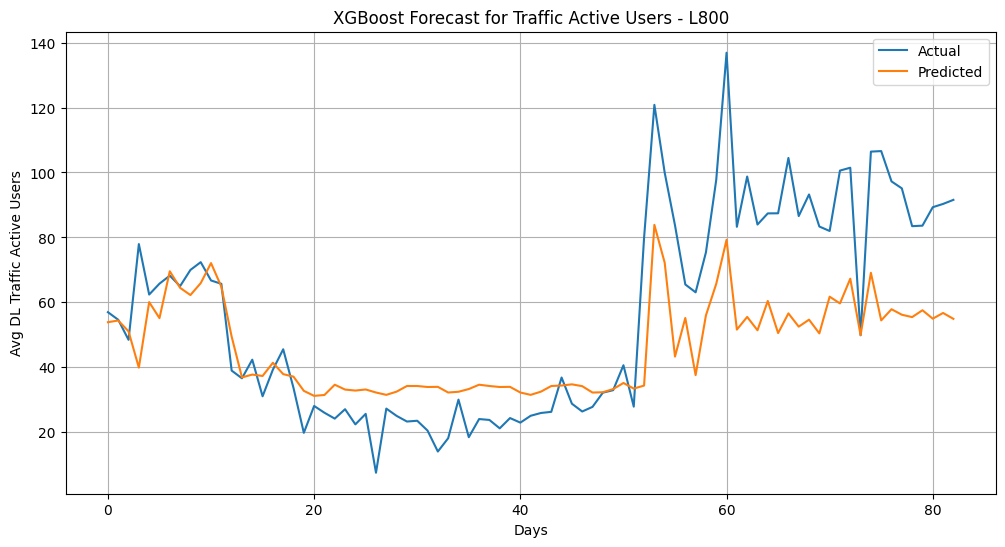

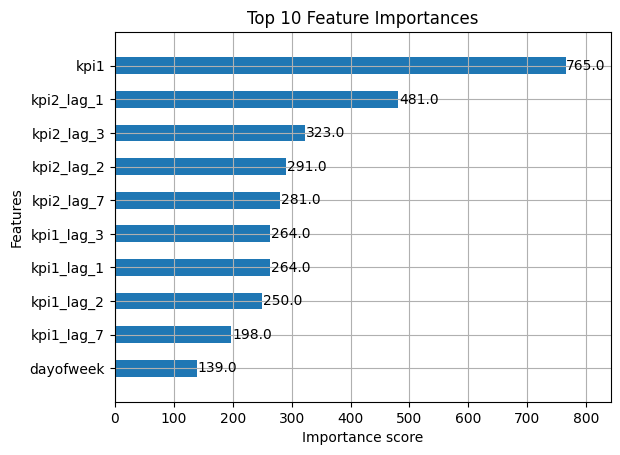

In [7]:
model, y_test, y_pred = train_xgb_on_kpi2(df_ml)

### L1800 Cell

In [8]:
df_ml = prepare_ml_dataset(df, '5001_KKO_DEGUEDOUMOU_3_L1800')

In [9]:
def train_xgb_on_kpi2(df_ml, target='kpi2', test_ratio=0.2):
    # 1. Split
    X = df_ml.drop(columns=['ds', target])
    y = df_ml[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)

    # 2. Train
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 3. Predict
    y_pred = model.predict(X_test)

    # 4. Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    print(f"XGBoost Forecast Evaluation for Traffic Active User - L1800")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # 5. Plot
    plt.figure(figsize=(12, 6))

    plt.plot(y_test.reset_index(drop=True), label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title("XGBoost Forecast for Traffic Active Users - L1800")
    plt.xlabel('Days')
    plt.ylabel('Avg DL Traffic Active Users')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 6. Feature importance
    xgb.plot_importance(model, height=0.5, max_num_features=10)
    plt.title("Top 10 Feature Importances")
    plt.show()

    return model, y_test, y_pred

XGBoost Forecast Evaluation for Traffic Active User - L1800
MAE: 27.37
RMSE: 36.57
MAPE: 94.20%


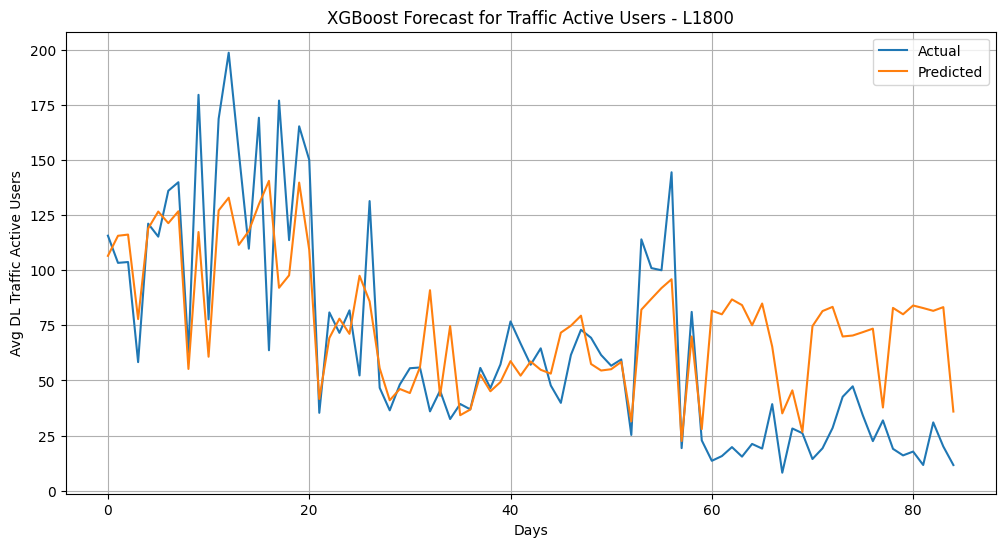

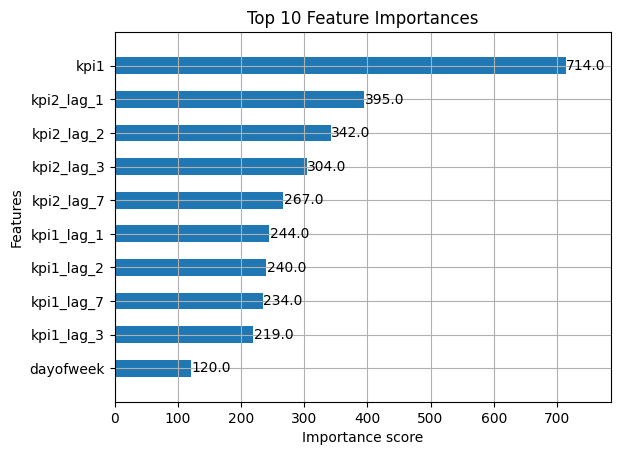

In [10]:
model, y_test, y_pred = train_xgb_on_kpi2(df_ml)

### L2600 Cell

In [11]:
df_ml = prepare_ml_dataset(df, '0446_KYS_KENIEBA_3_L2600')

In [12]:
def train_xgb_on_kpi2(df_ml, target='kpi2', test_ratio=0.2):
    # 1. Split
    X = df_ml.drop(columns=['ds', target])
    y = df_ml[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)

    # 2. Train
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 3. Predict
    y_pred = model.predict(X_test)

    # 4. Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    print(f"XGBoost Forecast Evaluation for Traffic Active User - L2600")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # 5. Plot
    plt.figure(figsize=(12, 6))

    plt.plot(y_test.reset_index(drop=True), label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title("XGBoost Forecast for Traffic Active Users - L2600")
    plt.xlabel('Days')
    plt.ylabel('Avg DL Traffic Active Users')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 6. Feature importance
    xgb.plot_importance(model, height=0.5, max_num_features=10)
    plt.title("Top 10 Feature Importances")
    plt.show()

    return model, y_test, y_pred

XGBoost Forecast Evaluation for Traffic Active User - L2600
MAE: 13.48
RMSE: 19.81
MAPE: 38.34%


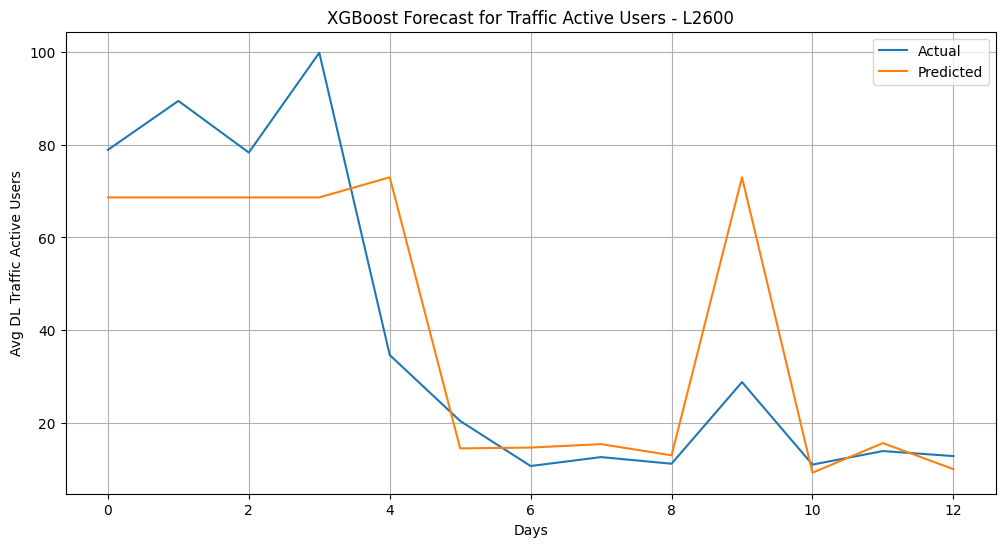

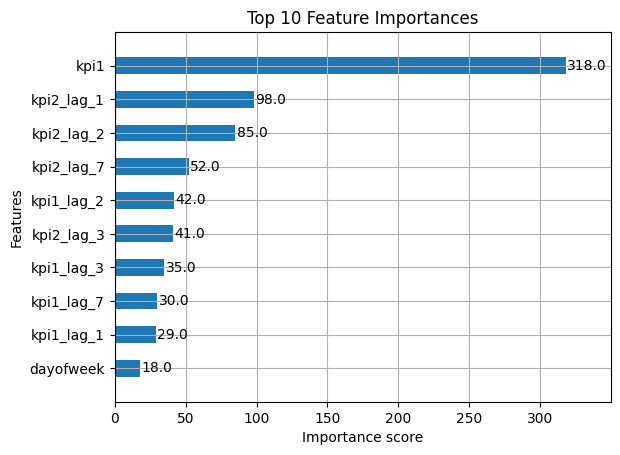

In [13]:
model, y_test, y_pred = train_xgb_on_kpi2(df_ml)

## Throughput Forecasting

In [14]:
def prepare_ml_dataset(df, cell_name, target_col='Avg_DL_User_Thrput_kbps',
                       lag_days=[1, 2, 3, 7], include_kpi1=True):
    df_cell = df[df['Cell_Name'] == cell_name].sort_values('Time').copy()

    # Rename for consistency
    df_cell = df_cell[['Time', 'Avg_DL_User_Thrput_kbps', 'Avg_DL_Traffic_Active_User']].copy()
    df_cell.rename(columns={'Time': 'ds', 'Avg_DL_User_Thrput_kbps': 'kpi1', 'Avg_DL_Traffic_Active_User': 'kpi2'}, inplace=True)

    # Create lag features for KPI 1 (target)
    for lag in lag_days:
        df_cell[f'kpi1_lag_{lag}'] = df_cell['kpi1'].shift(lag)

    # Add lag features for KPI 2
    if include_kpi1:
        for lag in lag_days:
            df_cell[f'kpi1_lag_{lag}'] = df_cell['kpi2'].shift(lag)

    # Add time features
    df_cell['dayofweek'] = df_cell['ds'].dt.dayofweek
    df_cell['month'] = df_cell['ds'].dt.month

    # Drop NA from lagging
    df_cell = df_cell.dropna().reset_index(drop=True)

    return df_cell

### L800 Cell

In [15]:
df_ml = prepare_ml_dataset(df, '4262_KYS_KENIEBA_3_L800')

In [18]:
def train_xgb_on_kpi1(df_ml, target='kpi1', test_ratio=0.2):
    # 1. Split
    X = df_ml.drop(columns=['ds', target])
    y = df_ml[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)

    # 2. Train
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 3. Predict
    y_pred = model.predict(X_test)

    # 4. Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    print(f"XGBoost Forecast Evaluation for Traffic Active User - L800")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # 5. Plot
    plt.figure(figsize=(12, 6))

    plt.plot(y_test.reset_index(drop=True), label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title("XGBoost Forecast for Throughput - L1800")
    plt.xlabel('Days')
    plt.ylabel('Avg DL User Throughput kbps')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 6. Feature importance
    xgb.plot_importance(model, height=0.5, max_num_features=10)
    plt.title("Top 10 Feature Importances")
    plt.show()

    return model, y_test, y_pred

XGBoost Forecast Evaluation for Traffic Active User - L800
MAE: 462.62
RMSE: 660.54
MAPE: 27.89%


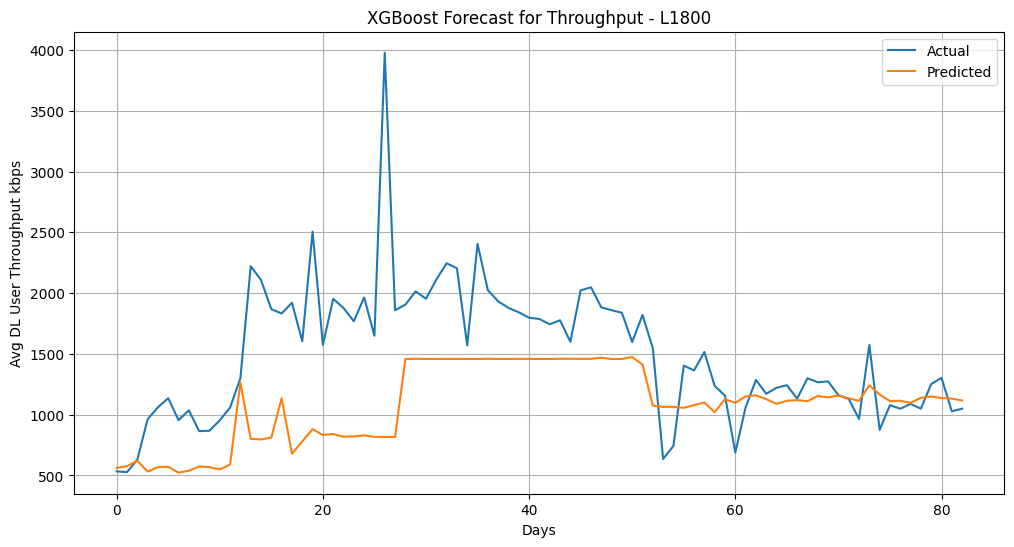

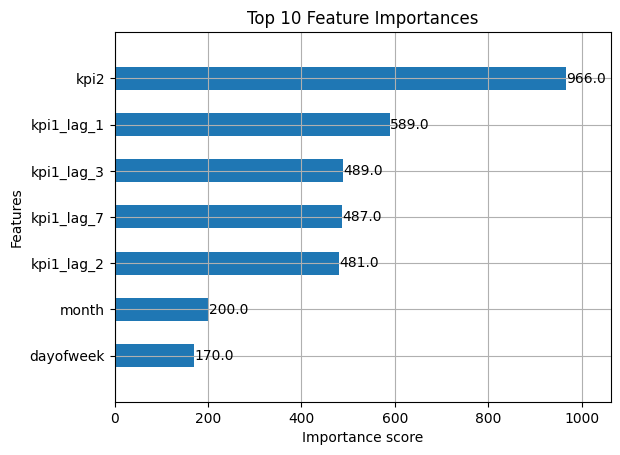

In [19]:
model, y_test, y_pred = train_xgb_on_kpi1(df_ml)

### L1800 Cell

In [20]:
df_ml = prepare_ml_dataset(df, '5001_KKO_DEGUEDOUMOU_3_L1800')

In [21]:
def train_xgb_on_kpi1(df_ml, target='kpi1', test_ratio=0.2):
    # 1. Split
    X = df_ml.drop(columns=['ds', target])
    y = df_ml[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)

    # 2. Train
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 3. Predict
    y_pred = model.predict(X_test)

    # 4. Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    print(f"XGBoost Forecast Evaluation for Traffic Active User - L800")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # 5. Plot
    plt.figure(figsize=(12, 6))

    plt.plot(y_test.reset_index(drop=True), label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title("XGBoost Forecast for Throughput - L1800")
    plt.xlabel('Days')
    plt.ylabel('Avg DL User Throughput kbps')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 6. Feature importance
    xgb.plot_importance(model, height=0.5, max_num_features=10)
    plt.title("Top 10 Feature Importances")
    plt.show()

    return model, y_test, y_pred

XGBoost Forecast Evaluation for Traffic Active User - L800
MAE: 1255.35
RMSE: 1840.65
MAPE: 44.65%


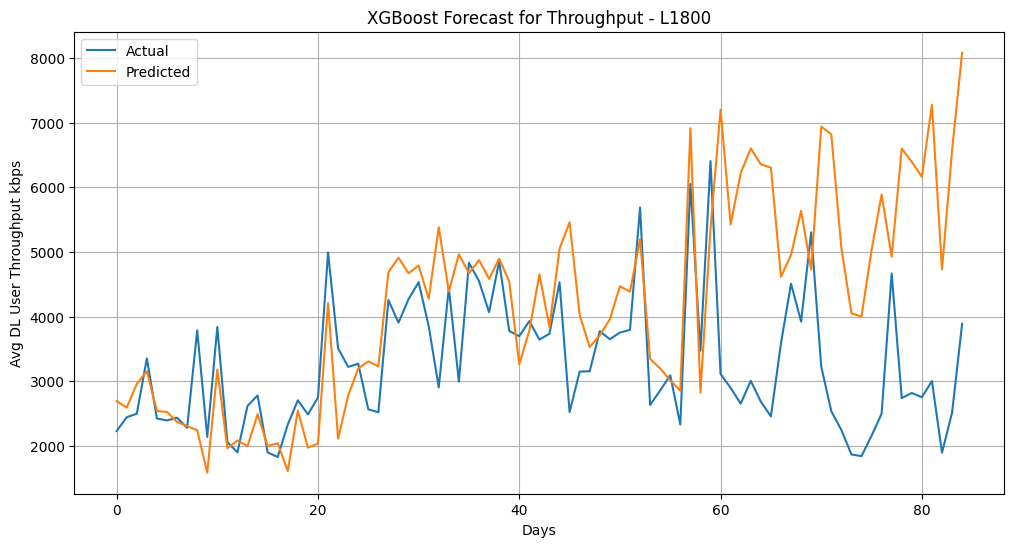

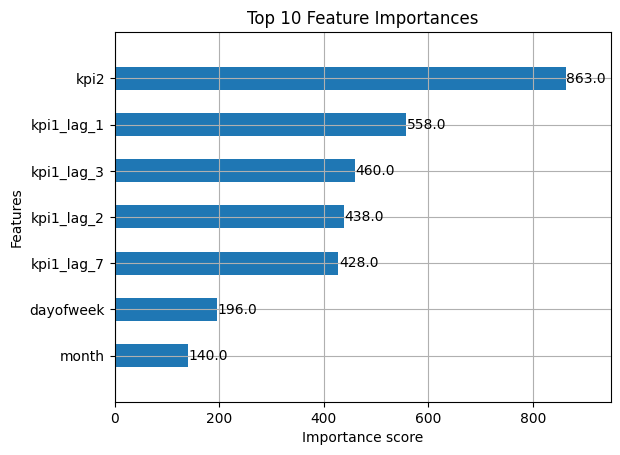

In [22]:
model, y_test, y_pred = train_xgb_on_kpi1(df_ml)

### L2600 Cell

In [23]:
df_ml = prepare_ml_dataset(df, '0446_KYS_KENIEBA_3_L2600')

In [24]:
def train_xgb_on_kpi1(df_ml, target='kpi1', test_ratio=0.2):
    # 1. Split
    X = df_ml.drop(columns=['ds', target])
    y = df_ml[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)

    # 2. Train
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 3. Predict
    y_pred = model.predict(X_test)

    # 4. Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    print(f"XGBoost Forecast Evaluation for Traffic Active User - L800")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # 5. Plot
    plt.figure(figsize=(12, 6))

    plt.plot(y_test.reset_index(drop=True), label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title("XGBoost Forecast for Throughput - L1800")
    plt.xlabel('Days')
    plt.ylabel('Avg DL User Throughput kbps')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 6. Feature importance
    xgb.plot_importance(model, height=0.5, max_num_features=10)
    plt.title("Top 10 Feature Importances")
    plt.show()

    return model, y_test, y_pred

XGBoost Forecast Evaluation for Traffic Active User - L800
MAE: 823.52
RMSE: 923.63
MAPE: 39.29%


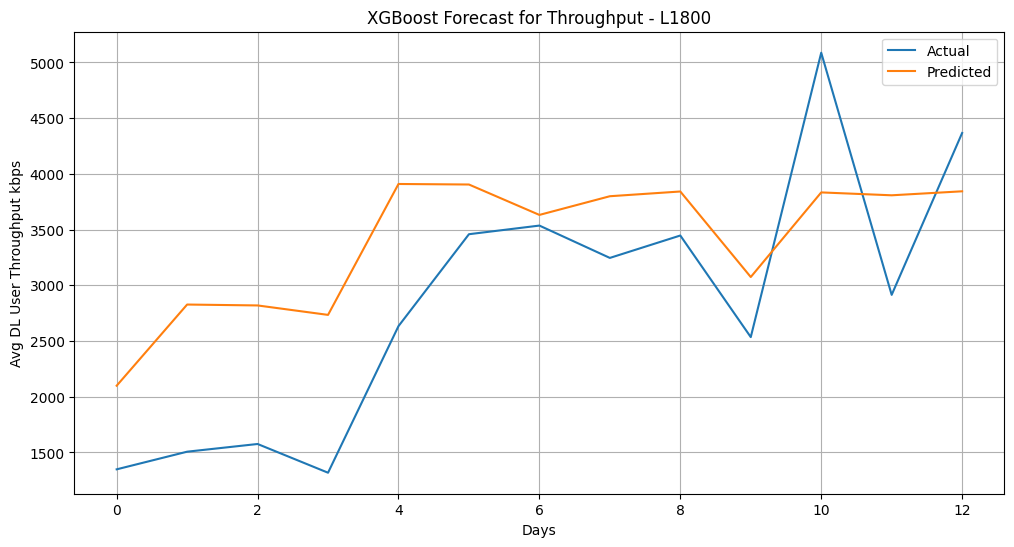

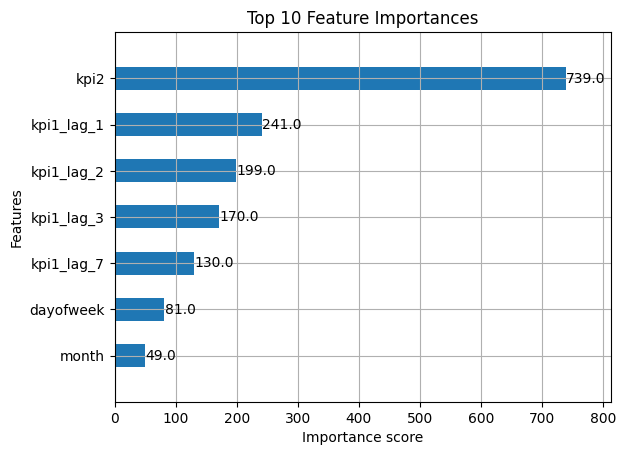

In [25]:
model, y_test, y_pred = train_xgb_on_kpi1(df_ml)